In [1]:
library(data.table)
library(ggplot2)
library(eulerr)
library(dplyr)


Warning message:
“package ‘data.table’ was built under R version 4.4.2”
Warning message:
“package ‘ggplot2’ was built under R version 4.4.1”
Warning message:
“package ‘eulerr’ was built under R version 4.4.3”
Warning message:
“package ‘dplyr’ was built under R version 4.4.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
or_res_cohort_wise <- fread("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/drop_runs/drop_master_202502_allGenes/processed_results/aberrant_expression/v19/outrider/aggregated_outliers.tsv")
py_or_res <- fread("/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/py_outrider_runs/all_cohorts/oht_cov_diag_lr_0_0001_epoc200_gpu/protrider_summary.csv")
py_or_res_aberrant <- py_or_res[aberrant == T]
or_res_cohort_wise[, sample_gene := paste0(sampleID, "_", geneID)]
py_or_res_aberrant[, sample_gene := paste0(sampleID, "_", geneID)]
or_res_cohort_wise <- or_res_cohort_wise[order(pValue)]
py_or_res_aberrant <- py_or_res_aberrant[order(pValue)]



In [3]:
variant_base_path <- "/omics/odcf/analysis/hipo/hipo_021/outlier_analysis/vcf/vep_res_aggregated/"
benchmark_criteria <- "HIGH"
snv_vep_res <- fread(paste0(variant_base_path, "vep_res_rare_snv_", benchmark_criteria, "_aggregated.tsv"))
indel_vep_res <- fread(paste0(variant_base_path, "vep_res_rare_indel_", benchmark_criteria, "_aggregated.tsv"))

vep_res_combinded <- rbind(snv_vep_res, indel_vep_res)

print(nrow(vep_res_combinded))

# Unique_based_on_criteria
if (benchmark_criteria == "CADD_PHRED"){
  vep_res_combinded <- snv_vep_res[order(-CADD_PHRED)][, .SD[1], by = .(sampleID, Gene)]
} else{
  vep_res_combinded <- vep_res_combinded[, IMPACT := factor(IMPACT, levels = c("HIGH", "MODERATE", "LOW", "MODIFIER"), ordered = TRUE)]
  setorder(vep_res_combinded, Gene, sampleID, IMPACT)
}

vep_res_combinded <- unique(vep_res_combinded, by = c("Gene", "sampleID"))
print(nrow(vep_res_combinded))


[1] 664718
[1] 224131


In [4]:
py_or_res_aberrant[, geneID:= sub("\\..*", "", geneID)]
py_or_res_aberrant <- left_join(py_or_res_aberrant, vep_res_combinded[, c("Gene", "sampleID", "IMPACT")], by=c("geneID" = "Gene", "sampleID"))

or_res_cohort_wise[, geneID:= sub("\\..*", "", geneID)]
or_res_cohort_wise <- left_join(or_res_cohort_wise, vep_res_combinded[, c("Gene", "sampleID", "IMPACT")], by=c("geneID" = "Gene", "sampleID"))


In [5]:
py_or_res_aberrant_sub <-  py_or_res_aberrant[padjust <= 0.05]
or_res_cohort_wise_sub <- or_res_cohort_wise


sum(as.integer(py_or_res_aberrant_sub$IMPACT), na.rm = TRUE)
sum(as.integer(or_res_cohort_wise$IMPACT), na.rm = TRUE)

joined <- inner_join(py_or_res_aberrant_sub, or_res_cohort_wise_sub, by=c("sapmle_gene", "IMPACT"))
sum(as.integer(joined$IMPACT), na.rm = TRUE)

set1 <- py_or_res_aberrant_sub$sample_gene
set2 <- or_res_cohort_wise$sample_gene

set1_ln <- length(set1)
set2_ln <- length(set2)

intersect_ln <- length(intersect(set1, set2))
fit <- euler(c(all_samples = (set1_ln - intersect_ln), cohort_wise = (set2_ln - intersect_ln), "all_samples&cohort_wise" = intersect_ln))
plot(fit, quantities = TRUE)

[1] 1232

[1] 589

ERROR: [1m[33mError[39m in `inner_join()`:[22m
[1m[22m[33m![39m Join columns in `x` must be present in the data.
[31m✖[39m Problem with `sapmle_gene`.


[1] 856

[1] 589

[1] 447

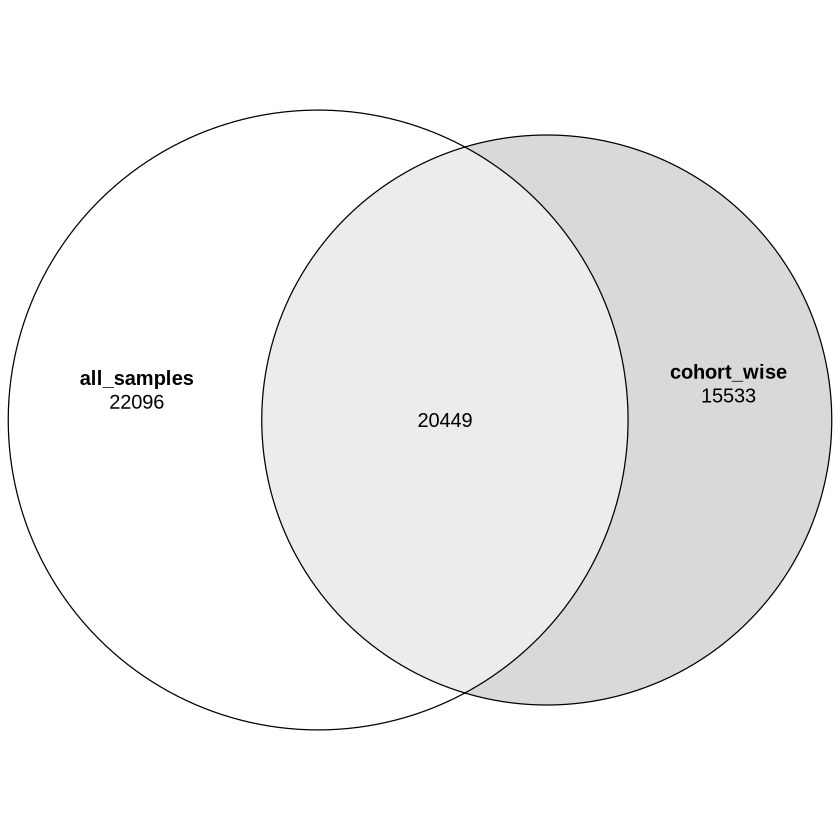

In [123]:
py_or_res_aberrant_sub <-  py_or_res_aberrant[padjust <= 0.005]
or_res_cohort_wise_sub <- or_res_cohort_wise


sum(as.integer(py_or_res_aberrant_sub$IMPACT), na.rm = TRUE)
sum(as.integer(or_res_cohort_wise$IMPACT), na.rm = TRUE)

joined <- inner_join(py_or_res_aberrant_sub, or_res_cohort_wise_sub, by=c("sapmle_gene", "IMPACT"))
sum(as.integer(joined$IMPACT), na.rm = TRUE)

set1 <- py_or_res_aberrant[padjust <= 0.005]$sample_gene
set2 <- or_res_cohort_wise$sample_gene

set1_ln <- length(set1)
set2_ln <- length(set2)

intersect_ln <- length(intersect(set1, set2))
fit <- euler(c(all_samples = (set1_ln - intersect_ln), cohort_wise = (set2_ln - intersect_ln), "all_samples&cohort_wise" = intersect_ln))
plot(fit, quantities = TRUE)

[1] 21

[1] 22

[1] 14

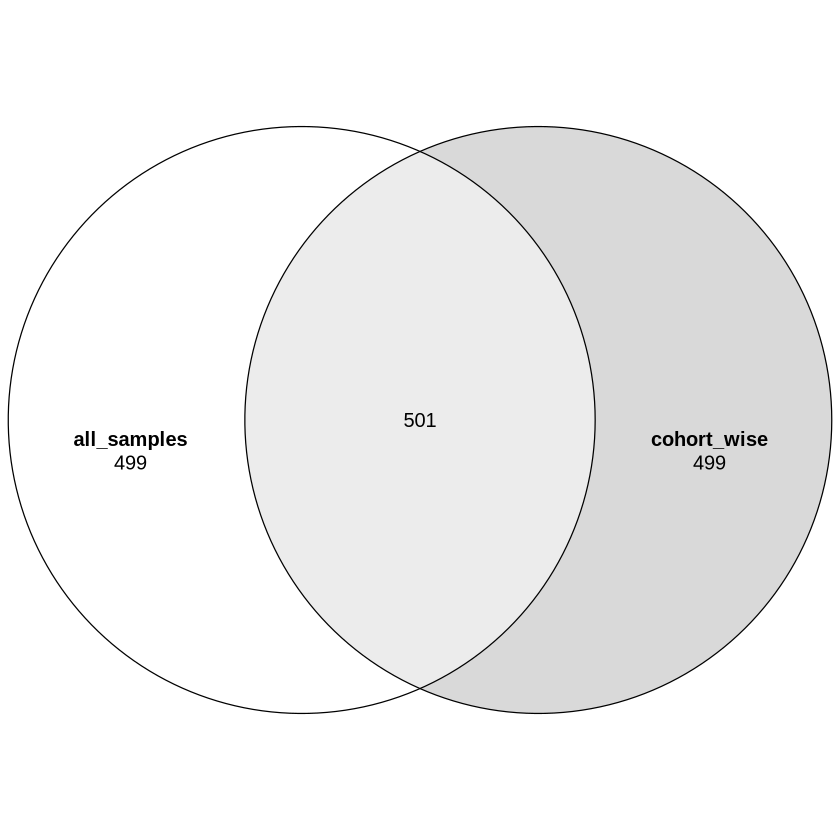

In [120]:
py_or_res_aberrant_sub <-  py_or_res_aberrant[1:1000]
or_res_cohort_wise_sub <- or_res_cohort_wise[1:1000]



sum(as.integer(py_or_res_aberrant_sub$IMPACT), na.rm = TRUE)
sum(as.integer(or_res_cohort_wise_sub$IMPACT), na.rm = TRUE)


joined <- inner_join(py_or_res_aberrant_sub, or_res_cohort_wise_sub, by=c("sapmle_gene", "IMPACT"))
sum(as.integer(joined$IMPACT), na.rm = TRUE)



set1 <- py_or_res_aberrant[1:1000]$sample_gene
set2 <- or_res_cohort_wise[1:1000]$sample_gene

set1_ln <- length(set1)
set2_ln <- length(set2)

intersect_ln <- length(intersect(set1, set2))
fit <- euler(c(all_samples = (set1_ln - intersect_ln), cohort_wise = (set2_ln - intersect_ln), "all_samples&cohort_wise" = intersect_ln))
plot(fit, quantities = TRUE)

[1] 277

[1] 217

[1] 149

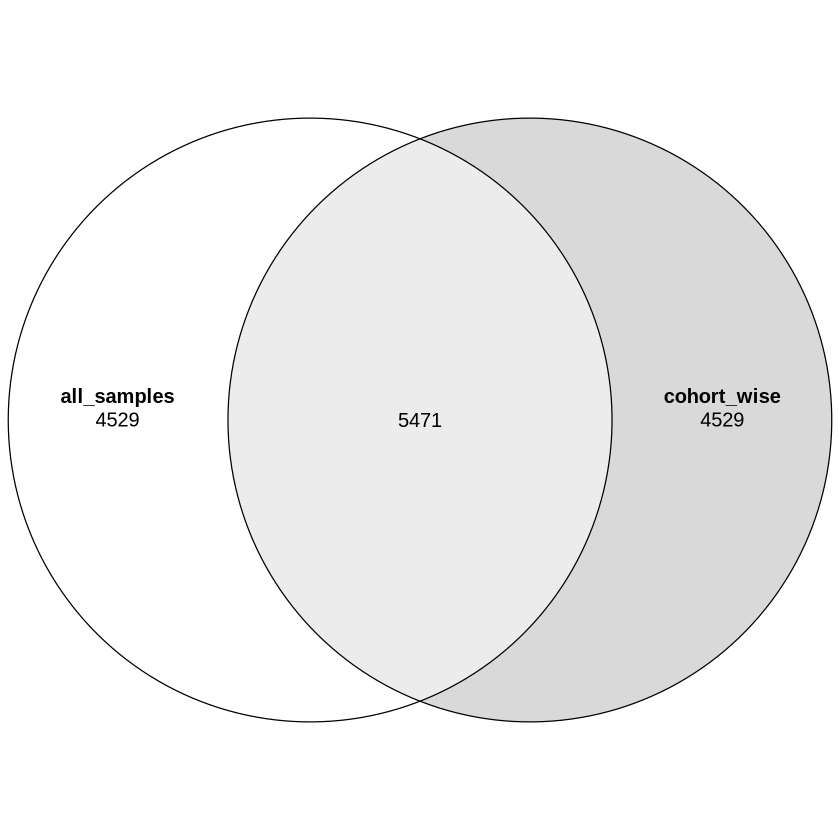

In [121]:
py_or_res_aberrant_sub <-  py_or_res_aberrant[1:10000]
or_res_cohort_wise_sub <- or_res_cohort_wise[1:10000]


sum(as.integer(py_or_res_aberrant_sub$IMPACT), na.rm = TRUE)
sum(as.integer(or_res_cohort_wise[1:10000]$IMPACT), na.rm = TRUE)

joined <- inner_join(py_or_res_aberrant_sub, or_res_cohort_wise_sub, by=c("sapmle_gene", "IMPACT"))
sum(as.integer(joined$IMPACT), na.rm = TRUE)



set1 <- py_or_res_aberrant[1:10000]$sample_gene
set2 <- or_res_cohort_wise[1:10000]$sample_gene

set1_ln <- length(set1)
set2_ln <- length(set2)

intersect_ln <- length(intersect(set1, set2))
fit <- euler(c(all_samples = (set1_ln - intersect_ln), cohort_wise = (set2_ln - intersect_ln), "all_samples&cohort_wise" = intersect_ln))
plot(fit, quantities = TRUE)

[1] 70

[1] 67

[1] 35

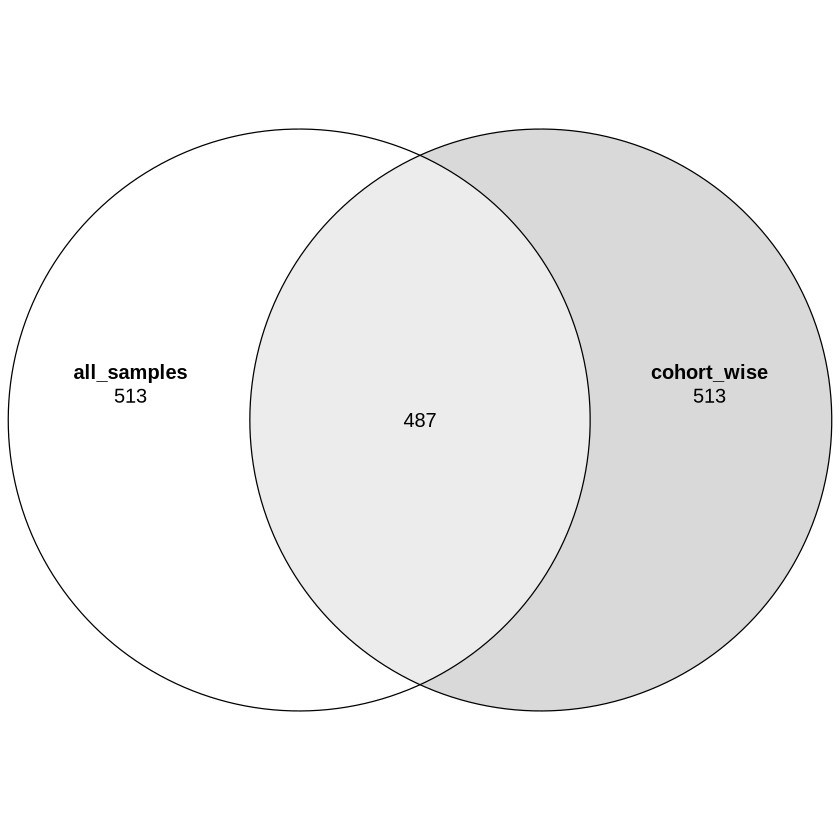

In [127]:
py_or_res_aberrant_sub <-  py_or_res_aberrant[zScore < 0][1:1000]
or_res_cohort_wise_sub <- or_res_cohort_wise[zScore < 0][1:1000]



sum(as.integer(py_or_res_aberrant_sub$IMPACT), na.rm = TRUE)
sum(as.integer(or_res_cohort_wise_sub$IMPACT), na.rm = TRUE)


joined <- inner_join(py_or_res_aberrant_sub, or_res_cohort_wise_sub, by=c("sapmle_gene", "IMPACT"))
sum(as.integer(joined$IMPACT), na.rm = TRUE)



set1 <- py_or_res_aberrant_sub$sample_gene
set2 <- or_res_cohort_wise_sub$sample_gene

set1_ln <- length(set1)
set2_ln <- length(set2)

intersect_ln <- length(intersect(set1, set2))
fit <- euler(c(all_samples = (set1_ln - intersect_ln), cohort_wise = (set2_ln - intersect_ln), "all_samples&cohort_wise" = intersect_ln))
plot(fit, quantities = TRUE)

[1] 516

[1] 391

[1] 301

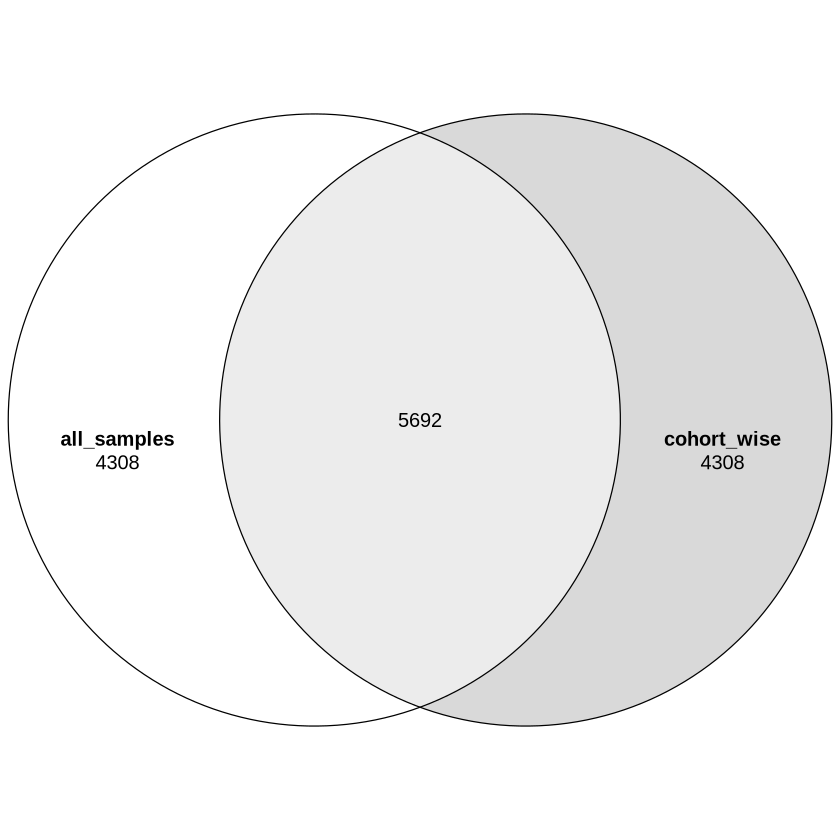

In [132]:
py_or_res_aberrant_sub <-  py_or_res_aberrant[zScore < 0][1:10000]
or_res_cohort_wise_sub <- or_res_cohort_wise[zScore < 0][1:10000]



sum(as.integer(py_or_res_aberrant_sub$IMPACT), na.rm = TRUE)
sum(as.integer(or_res_cohort_wise_sub$IMPACT), na.rm = TRUE)


joined <- inner_join(py_or_res_aberrant_sub, or_res_cohort_wise_sub, by=c("sapmle_gene", "IMPACT"))
sum(as.integer(joined$IMPACT), na.rm = TRUE)



set1 <- py_or_res_aberrant_sub$sample_gene
set2 <- or_res_cohort_wise_sub$sample_gene

set1_ln <- length(set1)
set2_ln <- length(set2)

intersect_ln <- length(intersect(set1, set2))
fit <- euler(c(all_samples = (set1_ln - intersect_ln), cohort_wise = (set2_ln - intersect_ln), "all_samples&cohort_wise" = intersect_ln))
plot(fit, quantities = TRUE)

[1] 750

[1] 518

[1] 400

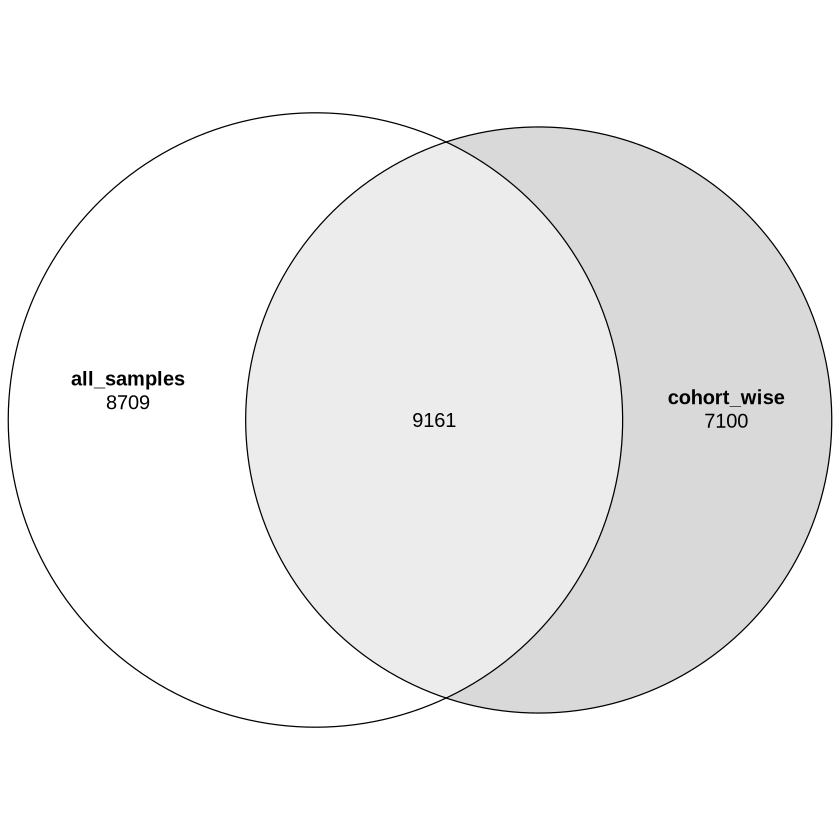

In [134]:
py_or_res_aberrant_sub <-  py_or_res_aberrant[zScore < 0 & padjust <= 0.005]
or_res_cohort_wise_sub <- or_res_cohort_wise[zScore < 0]


sum(as.integer(py_or_res_aberrant_sub$IMPACT), na.rm = TRUE)
sum(as.integer(or_res_cohort_wise_sub$IMPACT), na.rm = TRUE)

joined <- inner_join(py_or_res_aberrant_sub, or_res_cohort_wise_sub, by=c("sapmle_gene", "IMPACT"))
sum(as.integer(joined$IMPACT), na.rm = TRUE)

set1 <- py_or_res_aberrant_sub$sample_gene
set2 <- or_res_cohort_wise_sub$sample_gene

set1_ln <- length(set1)
set2_ln <- length(set2)

intersect_ln <- length(intersect(set1, set2))
fit <- euler(c(all_samples = (set1_ln - intersect_ln), cohort_wise = (set2_ln - intersect_ln), "all_samples&cohort_wise" = intersect_ln))
plot(fit, quantities = TRUE)

[1] 1082

[1] 518

[1] 451

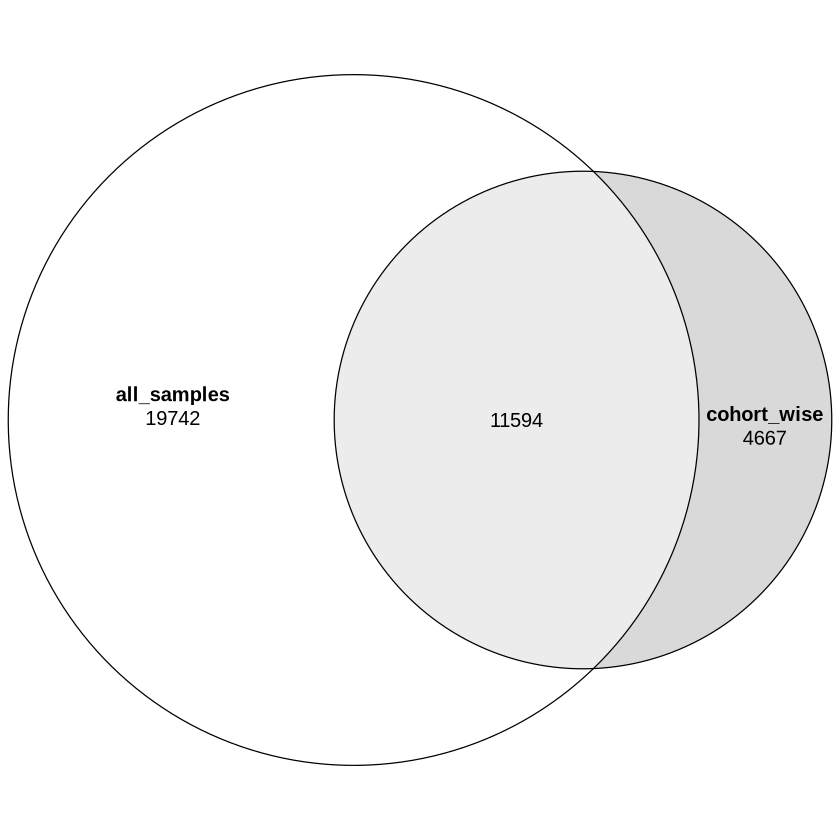

In [155]:
py_or_res_aberrant_sub <-  py_or_res_aberrant[zScore < 0 & padjust <= 0.05]
or_res_cohort_wise_sub <- or_res_cohort_wise[zScore < 0]


sum(as.integer(py_or_res_aberrant_sub$IMPACT), na.rm = TRUE)
sum(as.integer(or_res_cohort_wise_sub$IMPACT), na.rm = TRUE)

joined <- inner_join(py_or_res_aberrant_sub, or_res_cohort_wise_sub, by=c("sapmle_gene", "IMPACT"))
sum(as.integer(joined$IMPACT), na.rm = TRUE)

set1 <- py_or_res_aberrant_sub$sample_gene
set2 <- or_res_cohort_wise_sub$sample_gene

set1_ln <- length(set1)
set2_ln <- length(set2)

intersect_ln <- length(intersect(set1, set2))
fit <- euler(c(all_samples = (set1_ln - intersect_ln), cohort_wise = (set2_ln - intersect_ln), "all_samples&cohort_wise" = intersect_ln))
plot(fit, quantities = TRUE)

[1] 150

[1] 71

[1] 56

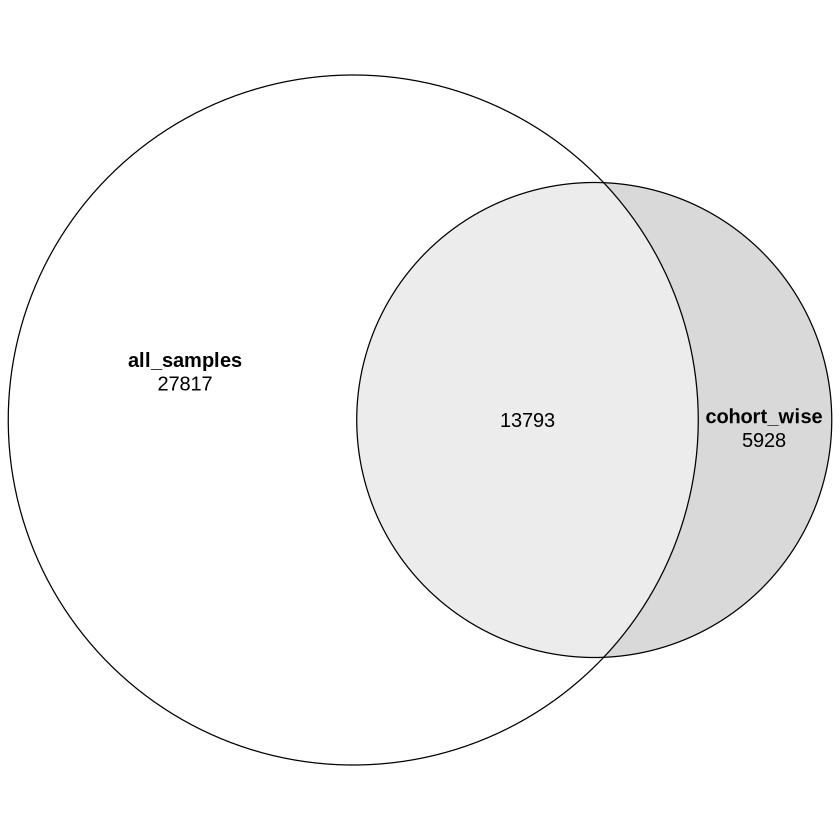

In [154]:
py_or_res_aberrant_sub <-  py_or_res_aberrant[zScore > 0 & padjust <= 0.05]
or_res_cohort_wise_sub <- or_res_cohort_wise[zScore > 0]


sum(as.integer(py_or_res_aberrant_sub$IMPACT), na.rm = TRUE)
sum(as.integer(or_res_cohort_wise_sub$IMPACT), na.rm = TRUE)

joined <- inner_join(py_or_res_aberrant_sub, or_res_cohort_wise_sub, by=c("sapmle_gene", "IMPACT"))
sum(as.integer(joined$IMPACT), na.rm = TRUE)

set1 <- py_or_res_aberrant_sub$sample_gene
set2 <- or_res_cohort_wise_sub$sample_gene

set1_ln <- length(set1)
set2_ln <- length(set2)

intersect_ln <- length(intersect(set1, set2))
fit <- euler(c(all_samples = (set1_ln - intersect_ln), cohort_wise = (set2_ln - intersect_ln), "all_samples&cohort_wise" = intersect_ln))
plot(fit, quantities = TRUE)

[1] 1232

[1] 589

[1] 507

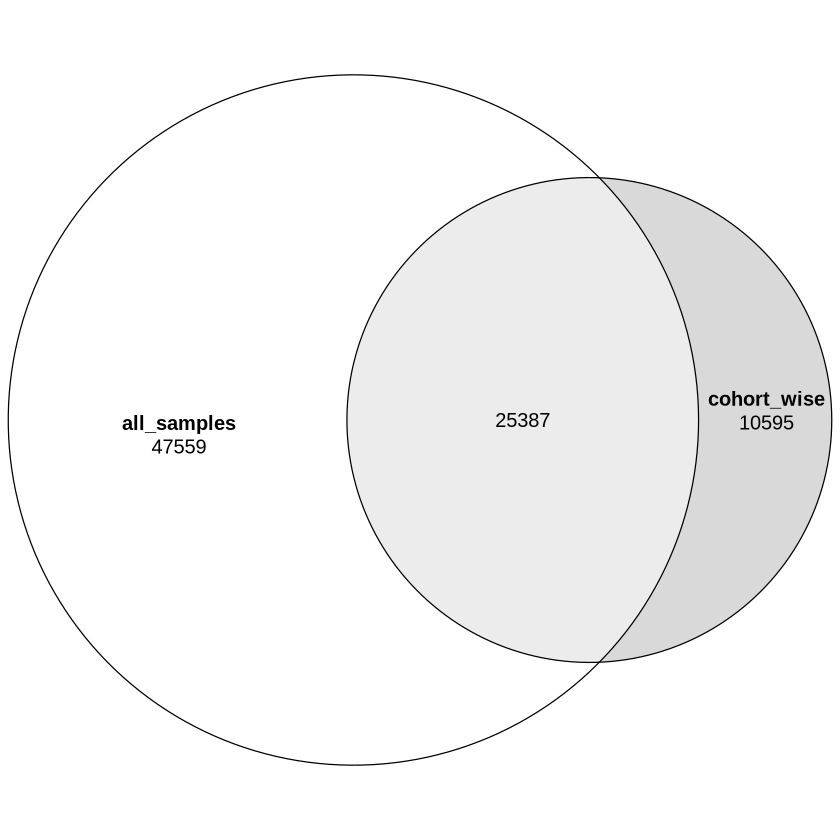

In [140]:
py_or_res_aberrant_sub <-  py_or_res_aberrant[padjust <= 0.05]
or_res_cohort_wise_sub <- or_res_cohort_wise


sum(as.integer(py_or_res_aberrant_sub$IMPACT), na.rm = TRUE)
sum(as.integer(or_res_cohort_wise_sub$IMPACT), na.rm = TRUE)

joined <- inner_join(py_or_res_aberrant_sub, or_res_cohort_wise_sub, by=c("sapmle_gene", "IMPACT"))
sum(as.integer(joined$IMPACT), na.rm = TRUE)

set1 <- py_or_res_aberrant_sub$sample_gene
set2 <- or_res_cohort_wise_sub$sample_gene

set1_ln <- length(set1)
set2_ln <- length(set2)

intersect_ln <- length(intersect(set1, set2))
fit <- euler(c(all_samples = (set1_ln - intersect_ln), cohort_wise = (set2_ln - intersect_ln), "all_samples&cohort_wise" = intersect_ln))
plot(fit, quantities = TRUE)

In [157]:
py_or_res_aberrant_sub <-  py_or_res_aberrant[zScore < 0 & padjust <= 0.005]
or_res_cohort_wise_sub <- or_res_cohort_wise[zScore < 0]



sum(as.integer(py_or_res_aberrant_sub$IMPACT), na.rm = TRUE)
sum(as.integer(or_res_cohort_wise_sub$IMPACT), na.rm = TRUE)

joined <- full_join(py_or_res_aberrant_sub, or_res_cohort_wise_sub, by=c("sapmle_gene", "IMPACT", "pValue"))
joined <- joined[order(pValue)]
sum(as.integer(joined$IMPACT), na.rm = TRUE)


[1] 750

[1] 518

[1] 1268